In [ ]:
from model.model import featurize_smiles, load_model

model = load_model("model/model.safetensors")  # MLP in eval mode

In [115]:
import polars as pl

bromides = pl.read_csv("../../data/glorius-bromides.csv")
smis = bromides["SMILES"].to_list()

In [116]:
X = featurize_smiles(smis)  # (n, 2048) ECFP4 features
logits = model(X)  # (n, 2): [class 0, class 1]
probs = logits.softmax(-1)  # (n, 2): [prob(class 0), prob(class 1)]
log_probs = logits.log_softmax(-1)
entropy = -(log_probs * probs).sum(axis=1)
print(probs)

tensor([[1.0000e+00, 1.0802e-09],
        [1.0000e+00, 5.3582e-07],
        [1.0000e+00, 4.0163e-07],
        ...,
        [1.0000e+00, 2.1346e-07],
        [8.3034e-01, 1.6966e-01],
        [7.0797e-01, 2.9203e-01]], grad_fn=<SoftmaxBackward0>)


In [117]:
max_probs = probs.detach().cpu().numpy().max(axis=1)
min_probs = probs.detach().cpu().numpy().min(axis=1)

Text(0.5, 1.0, 'Distribution of Prediction Entropy')

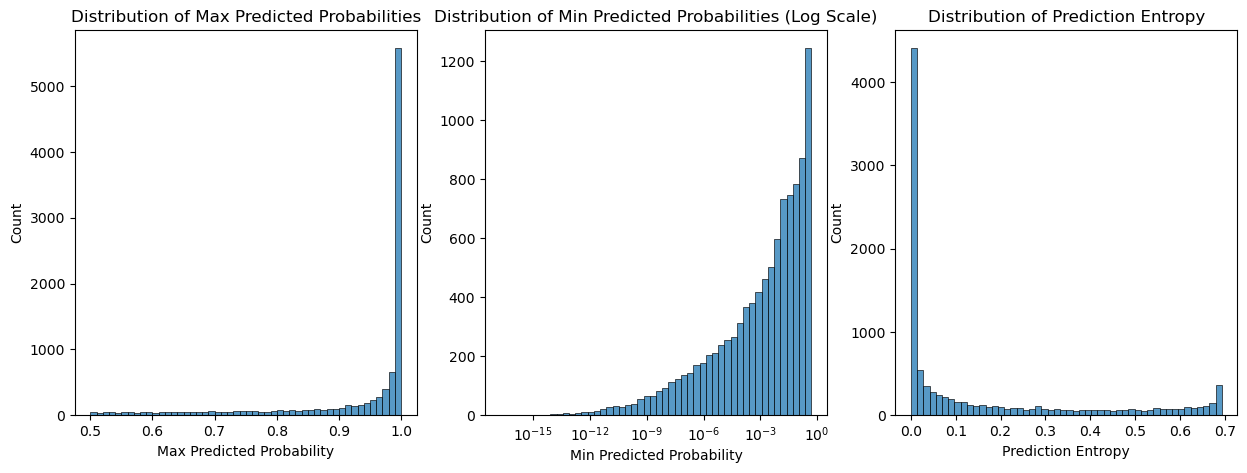

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(max_probs, bins=50, ax=axs[0])
axs[0].set_xlabel("Max Predicted Probability")
axs[0].set_title("Distribution of Max Predicted Probabilities")

sns.histplot(min_probs, bins=50, ax=axs[1], log_scale=True)
axs[1].set_xlabel("Min Predicted Probability")
axs[1].set_title("Distribution of Min Predicted Probabilities (Log Scale)")

sns.histplot(entropy.detach().cpu().numpy(), bins=50, ax=axs[2])
axs[2].set_xlabel("Prediction Entropy")
axs[2].set_title("Distribution of Prediction Entropy")

In [119]:
import torch

smallest_prob = torch.argmin(torch.Tensor(min_probs))
print(f"SMILES with smallest min prob: {smis[smallest_prob]}")

highest_prob = torch.argmax(torch.Tensor(min_probs))
print(f"SMILES with highest min prob: {smis[highest_prob]}")

SMILES with smallest min prob: CN(C)CCOc1cc(Br)c(F)cc1[N+](=O)[O-]
SMILES with highest min prob: CN(Cc1cc([N+](=O)[O-])ccc1Br)C(=O)OC(C)(C)C


In [120]:
smis[torch.argmax(torch.Tensor(max_probs))]

'O=Cc1ccc(Br)cc1'

<Axes: ylabel='Count'>

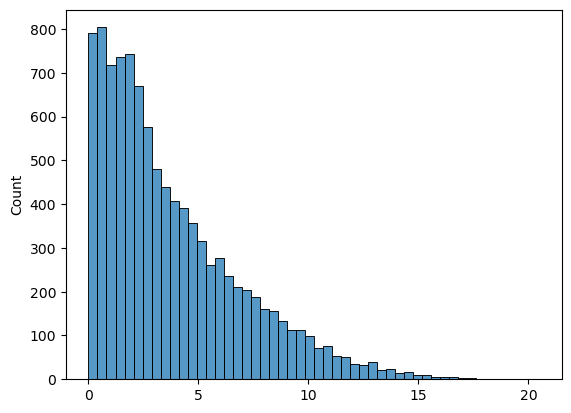

In [121]:
def rbf_kernel(entropy: torch.Tensor, tau: float = 0.5) -> torch.Tensor:
    return torch.exp(-entropy * tau)


def gaussian_kernel(entropy: torch.Tensor, sigma: float = 0.5) -> torch.Tensor:
    return torch.exp(-0.5 * (entropy / sigma) ** 2)


def sigmoid_kernel(
    entropy: torch.Tensor,
    loc: float = 0.0,
    scale: float = 1.0,
) -> torch.Tensor:
    return torch.sigmoid((entropy - loc) / scale)


sns.histplot(logits[:, 1].abs().detach().cpu().numpy(), bins=50)

<Axes: ylabel='Count'>

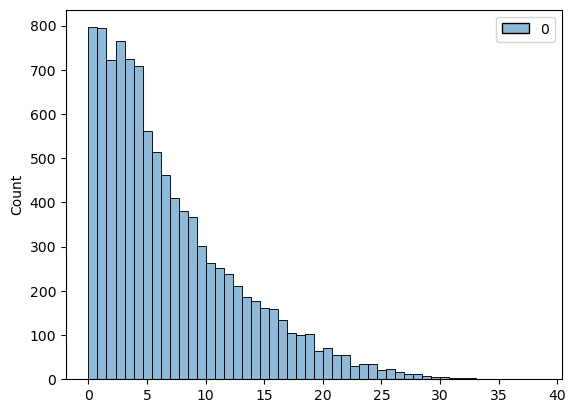

In [122]:
sns.histplot(logits.diff(dim=1).abs().detach().cpu().numpy(), bins=50)

<Axes: ylabel='Count'>

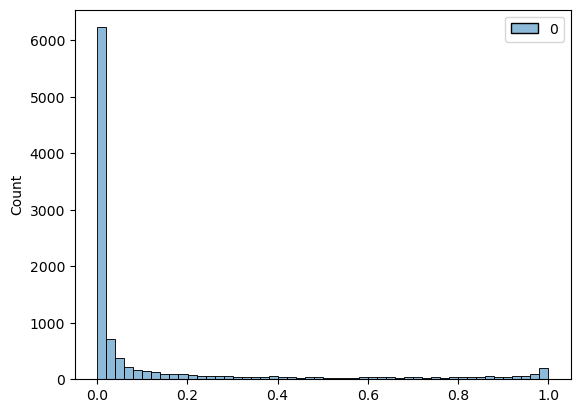

In [144]:
from torch.nn import functional as F

loc = 15
scale = 0.5

diff_logits = logits.diff(dim=1).abs()
score = F.sigmoid((diff_logits - loc) * scale)
sns.histplot(score.detach().cpu().numpy(), bins=50)

In [136]:
smi_to_score = pl.DataFrame(
    {
        "SMILES": smis,
        "Score": score.detach().squeeze().cpu().numpy(),
    },
)

top_scores = smi_to_score.sort("Score", descending=True).head(10)
top_scores.show()

SMILES,Score
str,f32
"""CN(C)CCOc1cc(Br)c(F)cc1[N+](=O…",1.0
"""Brc1ccc(/N=C/c2ccco2)cc1""",1.0
"""COC(=O)c1ccc(Br)c(CCN)c1""",0.999997
"""N[C@@H](CCC(=O)N[C@@H](CSCc1cc…",0.999997
"""Nc1ccc(Br)c(O)c1C(=O)O""",0.999995


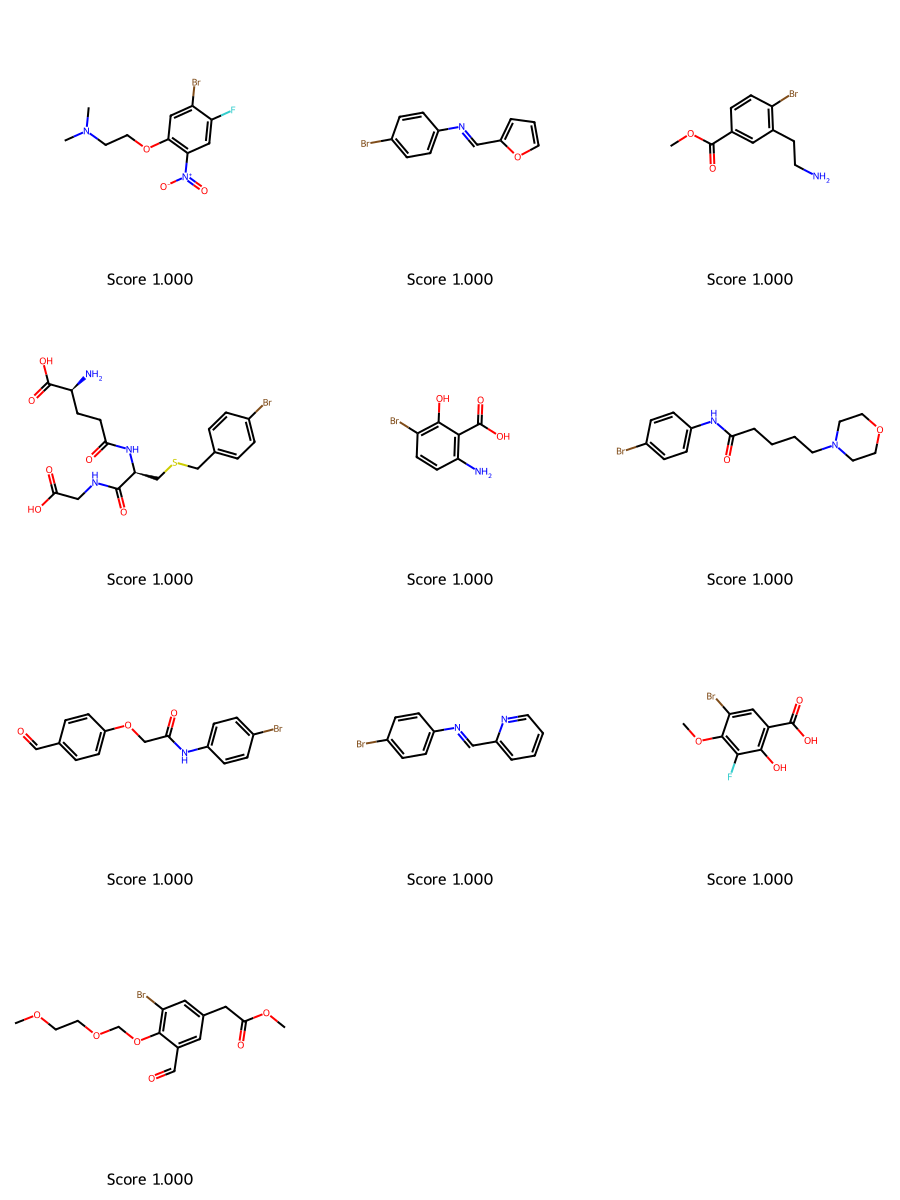

In [137]:
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.Draw import MolsToGridImage

mols = [MolFromSmiles(smi) for smi in top_scores["SMILES"]]
MolsToGridImage(
    mols,
    legends=[f"Score {score:.3f}" for score in top_scores["Score"]],
    molsPerRow=3,
    useSVG=True,
    subImgSize=(300, 300),
)

In [127]:
submission  = smi_to_score.sort("Score", descending=True).head(1000)
submission

SMILES,Score
str,f32
"""CN(C)CCOc1cc(Br)c(F)cc1[N+](=O…",0.999999
"""Brc1ccc(/N=C/c2ccco2)cc1""",0.999996
"""COC(=O)c1ccc(Br)c(CCN)c1""",0.999989
"""N[C@@H](CCC(=O)N[C@@H](CSCc1cc…",0.999988
"""Nc1ccc(Br)c(O)c1C(=O)O""",0.999985
…,…
"""Cc1cc([N+](=O)[O-])c(Br)cc1F""",0.946715
"""CNC(=O)c1ccccc1Br""",0.946423
"""O=Cc1cc(Br)cc(Cl)c1F""",0.94618


In [130]:
submission.select("SMILES").write_csv("submission.csv")